
# Supervised Learning: Linear vs Polynomial Regression (same dataset)

**Objetivo da aula:** comparar Regressão Linear com Regressão Polinomial no **mesmo conjunto de dados** para evidenciar *underfitting* (linear) vs melhor ajuste (polinomial).  
**O que você vai ver:**
1. Geração de dados sintéticos com relação levemente não linear
2. Divisão treino/teste
3. Treino do modelo de Regressão Linear
4. Treino do modelo de Regressão Polinomial (graus 2 e 3) com `Pipeline`
5. Avaliação com **MAE, MSE, RMSE, R²**
6. Visualizações com `matplotlib` (sem seaborn)


In [ ]:

# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Config de plots para o notebook (opcional)
%matplotlib inline



## 1) Gerar dados sintéticos
Criamos um dataset com **1 feature** (fácil de visualizar) e uma relação **quadrática** com ruído.




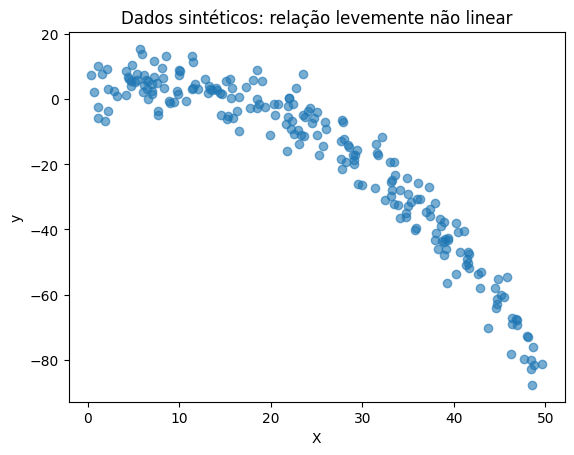

In [ ]:

# Semente para reprodutibilidade
rng = np.random.default_rng(42)

# Tamanho do dataset
n = 220

# Feature X (ex.: tempo de uso de um equipamento, área do imóvel, etc.)
X = rng.uniform(0, 50, size=n).reshape(-1, 1)

# Relação verdadeira (levemente não-linear): y = 2 + 0.8x - 0.05x^2 + noise
noise = rng.normal(0, 5, size=n)
y = 2 + 0.8 * X.squeeze() - 0.05 * (X.squeeze() ** 2) + noise

# Visualização rápida dos dados brutos
plt.figure()
plt.scatter(X, y, alpha=0.6)
plt.title("Dados sintéticos: relação levemente não linear")
plt.xlabel("X")
plt.ylabel("y")
plt.show()



## 2) Dividir em treino e teste
Separar dados de **treino** e **teste** ajuda a medir generalização (evitar overfitting).


In [ ]:

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=123)

len(X_tr), len(X_te)


(165, 55)


## 3) Regressão Linear
Ajusta uma **reta** (hiperplano) aos dados. Boa referência básica; pode subajustar relações não lineares.


In [ ]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)   # cálculo manual da raiz quadrada
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_tr, y_tr)

# Previsões
y_pred_lin_tr = lin_reg.predict(X_tr)
y_pred_lin_te = lin_reg.predict(X_te)

# Avaliação
lin_mae_tr, lin_mse_tr, lin_rmse_tr, lin_r2_tr = metrics(y_tr, y_pred_lin_tr)
lin_mae_te, lin_mse_te, lin_rmse_te, lin_r2_te = metrics(y_te, y_pred_lin_te)

# Resultados
print("Linear Regression — Coeficientes:")
print(f"  intercept = {lin_reg.intercept_:.3f}")
print(f"  coef      = {lin_reg.coef_.ravel()}")

print("\nLinear Regression — Métricas:")
print(f"  Train -> MAE={lin_mae_tr:.3f}  MSE={lin_mse_tr:.3f}  RMSE={lin_rmse_tr:.3f}  R2={lin_r2_tr:.3f}")
print(f"  Test  -> MAE={lin_mae_te:.3f}  MSE={lin_mse_te:.3f}  RMSE={lin_rmse_te:.3f}  R2={lin_r2_te:.3f}")


Linear Regression — Coeficientes:
  intercept = 20.830
  coef      = [-1.60740302]

Linear Regression — Métricas:
  Train -> MAE=8.327  MSE=109.688  RMSE=10.473  R2=0.829
  Test  -> MAE=8.006  MSE=90.293  RMSE=9.502  R2=0.866



## 4) Regressão Polinomial (graus 2 e 3)
Criamos novas features como \(x^2, x^3\) via `PolynomialFeatures` e aplicamos `LinearRegression` sobre esse *feature space*. Usamos `Pipeline` para organizar o fluxo.


In [ ]:

poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])
poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linreg", LinearRegression())
])

poly2.fit(X_tr, y_tr)
poly3.fit(X_tr, y_tr)

y_pred_p2_tr = poly2.predict(X_tr)
y_pred_p2_te = poly2.predict(X_te)
y_pred_p3_tr = poly3.predict(X_tr)
y_pred_p3_te = poly3.predict(X_te)

p2_mae_tr, p2_mse_tr, p2_rmse_tr, p2_r2_tr = metrics(y_tr, y_pred_p2_tr)
p2_mae_te, p2_mse_te, p2_rmse_te, p2_r2_te = metrics(y_te, y_pred_p2_te)

p3_mae_tr, p3_mse_tr, p3_rmse_tr, p3_r2_tr = metrics(y_tr, y_pred_p3_tr)
p3_mae_te, p3_mse_te, p3_rmse_te, p3_r2_te = metrics(y_te, y_pred_p3_te)

print("Polynomial deg=2 — Métricas:")
print(f"  Train -> MAE={p2_mae_tr:.3f}  MSE={p2_mse_tr:.3f}  RMSE={p2_rmse_tr:.3f}  R2={p2_r2_tr:.3f}")
print(f"  Test  -> MAE={p2_mae_te:.3f}  MSE={p2_mse_te:.3f}  RMSE={p2_rmse_te:.3f}  R2={p2_r2_te:.3f}")

print("\nPolynomial deg=3 — Métricas:")
print(f"  Train -> MAE={p3_mae_tr:.3f}  MSE={p3_mse_tr:.3f}  RMSE={p3_rmse_tr:.3f}  R2={p3_r2_tr:.3f}")
print(f"  Test  -> MAE={p3_mae_te:.3f}  MSE={p3_mse_te:.3f}  RMSE={p3_rmse_te:.3f}  R2={p3_r2_te:.3f}")


Polynomial deg=2 — Métricas:
  Train -> MAE=4.323  MSE=29.005  RMSE=5.386  R2=0.955
  Test  -> MAE=3.144  MSE=17.313  RMSE=4.161  R2=0.974

Polynomial deg=3 — Métricas:
  Train -> MAE=4.301  MSE=28.717  RMSE=5.359  R2=0.955
  Test  -> MAE=3.139  MSE=16.977  RMSE=4.120  R2=0.975



## 5) Comparar métricas (tabela)
Consolidamos **MAE, MSE, RMSE e R²** para comparar desempenho em treino e teste.


In [ ]:

rows = [
    ["Linear", lin_mae_tr, lin_mse_tr, lin_rmse_tr, lin_r2_tr, lin_mae_te, lin_mse_te, lin_rmse_te, lin_r2_te],
    ["Poly deg=2", p2_mae_tr, p2_mse_tr, p2_rmse_tr, p2_r2_tr, p2_mae_te, p2_mse_te, p2_rmse_te, p2_r2_te],
    ["Poly deg=3", p3_mae_tr, p3_mse_tr, p3_rmse_tr, p3_r2_tr, p3_mae_te, p3_mse_te, p3_rmse_te, p3_r2_te],
]
results = pd.DataFrame(rows, columns=[
    "Model", "MAE (train)", "MSE (train)", "RMSE (train)", "R2 (train)",
    "MAE (test)", "MSE (test)", "RMSE (test)", "R2 (test)"
])
results.round(4)


,Model,MAE (train),MSE (train),RMSE (train),R2 (train),MAE (test),MSE (test),RMSE (test),R2 (test)
0,Linear,8.3268,109.6875,10.4732,0.8285,8.0055,90.2932,9.5023,0.8661
1,Poly deg=2,4.3229,29.0053,5.3857,0.9547,3.1442,17.3127,4.1609,0.9743
2,Poly deg=3,4.3010,28.7171,5.3588,0.9551,3.1391,16.9770,4.1203,0.9748



## 6) Visualizações
- **Gráfico 1:** dados + ajuste linear  
- **Gráfico 2:** dados + ajustes polinomiais (grau 2 e 3)

> Observação didática: espere ver o linear subajustando (*underfitting*) e o polinomial acompanhando melhor a curvatura verdadeira.


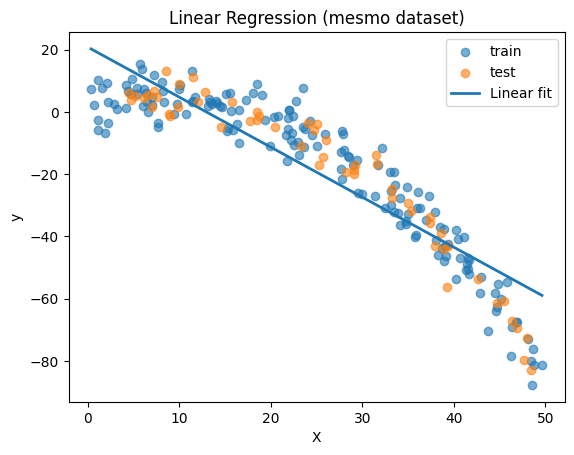

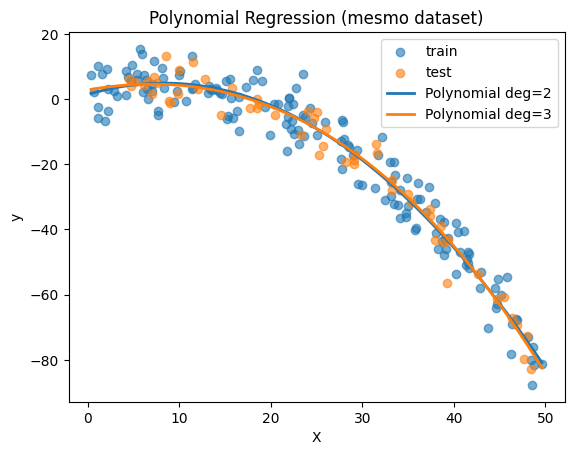

In [ ]:

# Grade para curvas suaves
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
y_grid_lin = lin_reg.predict(x_grid)
y_grid_p2 = poly2.predict(x_grid)
y_grid_p3 = poly3.predict(x_grid)

# Plot 1: Linear
plt.figure()
plt.scatter(X_tr, y_tr, alpha=0.6, label="train")
plt.scatter(X_te, y_te, alpha=0.6, label="test")
plt.plot(x_grid, y_grid_lin, linewidth=2, label="Linear fit")
plt.title("Linear Regression (mesmo dataset)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Plot 2: Polynomial
plt.figure()
plt.scatter(X_tr, y_tr, alpha=0.6, label="train")
plt.scatter(X_te, y_te, alpha=0.6, label="test")
plt.plot(x_grid, y_grid_p2, linewidth=2, label="Polynomial deg=2")
plt.plot(x_grid, y_grid_p3, linewidth=2, label="Polynomial deg=3")
plt.title("Polynomial Regression (mesmo dataset)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
